In [1]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter("ignore")

SEED = 30

In [2]:
df_train = pd.read_csv("/kaggle/input/playground-series-s5e5/train.csv")
df_test = pd.read_csv("/kaggle/input/playground-series-s5e5/test.csv")

# Features

In [3]:
def make_sex_int(df, features):
    df_temp = df.copy()
    for feature in features:
        df_temp[f'{feature}_Male'] = df_temp[feature] * df_temp['Sex_male']
        df_temp[f'{feature}_Female'] = df_temp[feature] * (1-df_temp['Sex_male'])
    return df_temp

def make_custom_features(df):
    df_temp = df.copy()
    df_temp['BMI'] = df_temp['Weight'] / (df_temp['Height'] / 100) ** 2
    df_temp['Intensity'] = df_temp['Heart_Rate'] / df_temp['Duration']
    df_temp["HR_pct_max"] = df_temp["Heart_Rate"] / (220 - df_temp["Age"])
    df_temp['BMR']=0
    df_temp.loc[df_temp.Sex_male==1,'BMR'] = df_temp['Weight'] * 9.65 + (df_temp['Height'] / 100) * 573 - df_temp['Age'] * 5.08 + 260
    df_temp.loc[df_temp.Sex_male==0,'BMR'] = df_temp['Weight'] * 7.38 + (df_temp['Height'] / 100) * 607 - df_temp['Age'] * 2.31 + 43
    return df_temp

def make_aggregates(df):
    df_temp = df.copy()
    numerical_cols = ['Age', "Duration", "Heart_Rate", "Body_Temp"]
    cat_cols = ['Sex_male']
    agg_types = ['mean', 'min', 'max']
    for cat_col in cat_cols:
        for agg_type in agg_types:
            aggs = df_temp[numerical_cols] - df_temp.groupby(cat_col)[numerical_cols].transform(agg_type)
            aggs.columns = [f"{cat_col}_{num_col}_{agg_type}" for num_col in aggs.columns]
            df_temp = pd.concat([df_temp, aggs], axis=1)
    return df_temp

def make_log_features(df):
    df_temp = df.copy()
    num_features = list(df_temp.drop(columns=['Calories']).select_dtypes(include=['int64', 'float64']).columns)
    for feature in num_features:
        df_temp[f'log_{feature}'] = np.log(df_temp[feature])
    return df_temp

def make_all_int(df):
    df_temp = df.copy()
    features = list(df_temp.drop(columns=['Calories']).columns)
    for i in range(len(features)-1):
    # polynomial terms
        df_temp[f"{features[i]}2"] = df_temp.apply(lambda x: x[features[i]]**2, axis=1)
        df_temp[f"{features[i]}3"] = df_temp.apply(lambda x: x[features[i]]**3, axis=1)
        for j in range(i+1, len(features)-1):
            # interaction term
            df_temp[f"{features[i]}_{features[j]}"] = df_temp[features[i]] * df_temp[features[j]]
    return df_temp

def make_feature_set1(df, test=False, make_int=True):
    df_temp = df.copy()

    df_temp.drop(columns=['id'], inplace=True)
    
    # dummy encoding
    df_temp = pd.get_dummies(df_temp, columns=['Sex'], drop_first=True)
    df_temp = make_custom_features(df_temp)
    
    # df_temp = make_sex_int(df_temp, features=['Duration', 'Heart_Rate', 'Body_Temp', 'Age'])
    # df_temp = make_aggregates(df_temp)

    return df_temp

# for predicting log of outcome rather than just outcome
def make_outcome_log(df):
    df_temp = df.copy()

    df_temp['log_calories'] = np.log1p(df_temp['Calories'])
    
    return df_temp

df_train1 = make_feature_set1(df_train, make_int = False)
df_train2 = make_outcome_log(df_train)

In [4]:
# without the fancy features
X = df_train.drop(columns=['id', 'Calories'])
X['Sex'] = X['Sex'].astype('category')
y = df_train['Calories']

X_train0, X_val0, y_train0, y_val0 = train_test_split(X, y, test_size=0.3, random_state=SEED)

# with the fancy features
X1 = df_train1.drop(columns=['Calories'])
y1 = df_train1['Calories']
X_train1, X_val1, _, _ = train_test_split(X1, y1, test_size=0.3, random_state=SEED)

# with log calories
y2 = df_train2['log_calories']
_, _, y_train2, y_val2 = train_test_split(X, y2, test_size=0.3, random_state=SEED)

In [5]:
# Choose which dataset to use here
X = X1
y = y2
X_train = X_train1
X_val = X_val1
y_train = y_train2
y_val = y_val2

# Models

In [6]:
xgb_params =  {
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "gpu_hist",
    'learning_rate': 0.02, 
    'max_depth': 10, 
    'subsample': 0.8, 
    'colsample_bytree': 0.8, 
    'n_estimators': 3000,
    'early_stopping_rounds': 100,
    'enable_categorical': True,
    "random_state": SEED
}

cat_params = {'iterations': 3000,
               'depth': 9,
               'learning_rate': 0.035167955681486916,
               'l2_leaf_reg': 5.17625061368437,
               'border_count': 75,
               'random_strength': 0.4019388693662541,
               'bagging_temperature': 0.4397857731776691,
               "task_type": "GPU",
               "loss_function": "RMSE", 
               "bootstrap_type": "Bayesian",
               "verbose": 0,
               "random_seed": SEED,
               "early_stopping_rounds": 100,
              }

lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.02,
    "n_estimators": 3000, 
    "num_leaves": 20,  
    "max_depth": 8, 
    "min_child_samples": 20, 
    "min_split_gain": 0.01,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 1.0, 
    "reg_lambda": 1.0,
    "random_state": SEED,
    "verbosity": -1,
    "feature_fraction": 0.7,
    "force_col_wise": True
}

In [7]:
cat_features = list(X_train1.select_dtypes(include=['category']).columns)

def rmsle_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    y_pred = np.maximum(y_pred, 0)
    loss = np.sqrt(mean_squared_log_error(y_true, y_pred))
    return 'RMSLE', loss

### Meta Model by Neural Network

In [8]:
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm

In [9]:
input_size = 2

class Meta_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, X):
        return self.layers(X)

In [10]:
K = 10
kf = KFold(n_splits=K)

base_models = [
    XGBRegressor(**xgb_params),
    CatBoostRegressor(**cat_params, cat_features=cat_features),
    # LGBMRegressor(**lgb_params)
             ]
N_MODELS = len(base_models)

oof_train = np.zeros((len(X_train), N_MODELS))
val_preds = np.zeros((len(X_val), N_MODELS))

for m_idx, model in enumerate(base_models):
    val_fold_preds = []
    scores = []
    fold = 0
    model_name = None
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_v = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_v = y_train.iloc[train_idx], y_train.iloc[val_idx]
        fold += 1
        
        # Train base model on train fold
        if m_idx == 0: # xgboost
            model_name = 'XGB'
            model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)], verbose=False)
        elif m_idx == 1: # cat
            model_name = 'Cat'
            model.fit(X_tr, y_tr, eval_set=[(X_v, y_v)])
        else: # lgb
            model_name = 'LGB'
            model.fit(X_tr, y_tr)

        # Predict on validation fold and store in OOF matrix
        oof_train[val_idx, m_idx] = np.expm1(model.predict(X_v))

        # Predict on test data and save for averaging
        val_pred = np.expm1(model.predict(X_val))
        score = np.sqrt(mean_squared_log_error(val_pred, y_val0))
        scores.append(score)
        print(f"{model_name} fold {fold} val score: {score}")
        val_fold_preds.append(val_pred)

    avg_score = np.mean(scores)
    print(f"{model_name} Average Val Score: {avg_score}")
    val_preds[:, m_idx] = np.mean(val_fold_preds, axis=0)

XGB fold 1 val score: 0.06015838427837556
XGB fold 2 val score: 0.060085653456687024
XGB fold 3 val score: 0.0601701901652457
XGB fold 4 val score: 0.06011537695111492
XGB fold 5 val score: 0.059897512087565906
XGB fold 6 val score: 0.06018158809117286
XGB fold 7 val score: 0.06007163587797265
XGB fold 8 val score: 0.06007945559860985
XGB fold 9 val score: 0.06002386852776204
XGB fold 10 val score: 0.06014840708748925
XGB Average Val Score: 0.06009320721219959
Cat fold 1 val score: 0.05988599293251737
Cat fold 2 val score: 0.05985341191239765
Cat fold 3 val score: 0.059942373709089315
Cat fold 4 val score: 0.05988470539794478
Cat fold 5 val score: 0.059910438443454554
Cat fold 6 val score: 0.060028445431605355
Cat fold 7 val score: 0.05980161672404272
Cat fold 8 val score: 0.059922330170248596
Cat fold 9 val score: 0.05982004492176218
Cat fold 10 val score: 0.05979392040251306
Cat Average Val Score: 0.05988432800455756


In [11]:
class rmsle_loss_nn(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_act):
        y_pred = torch.clamp(y_pred, 0)
        loss = torch.mean((torch.log1p(y_pred) - torch.log1p(y_act))**2)
        return torch.sqrt(loss)

class rmse_loss_nn(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, y_pred, y_act):
        return torch.sqrt(torch.mean((y_pred - y_act)**2))

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [13]:
meta_model = Meta_NN().to(device)

learning_rate = 1e-3
EPOCHS = 100
BATCH_SIZE = 64

oof_train = torch.tensor(oof_train, dtype=torch.float32)
y_train0 = torch.tensor(y_train0, dtype=torch.float32)
dataset = TensorDataset(oof_train, y_train0)
loader = DataLoader(dataset, batch_size = BATCH_SIZE)

criterion = rmse_loss_nn()
optimizer = optim.Adam(meta_model.parameters(), lr=learning_rate)

all_train_loss = []
all_val_loss = []

torch.manual_seed(SEED)

for epoch in tqdm(range(EPOCHS)):
    meta_model.train()
    epoch_loss = 0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
    
        y_pred = meta_model(X_batch).squeeze()
        loss = criterion(y_pred, y_batch)
        epoch_loss += loss.item()
        
        loss.backward()
        optimizer.step()
    
    # validation
    epoch_loss /= len(loader)
    all_train_loss.append(epoch_loss)

    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"========== EPOCH :{epoch + 1} ==========")
        print(f"Training Loss: {epoch_loss}")

  1%|          | 1/100 [00:16<26:28, 16.04s/it]

========== EPOCH :1 ==========
Training Loss: 3.9086413804581546


 20%|██        | 20/100 [04:58<19:56, 14.96s/it]

========== EPOCH :20 ==========
Training Loss: 3.3738111647409905


 40%|████      | 40/100 [09:55<14:40, 14.68s/it]

...

========== EPOCH :60 ==========
Training Loss: 3.3619850932650888


 80%|████████  | 80/100 [19:31<04:43, 14.19s/it]

========== EPOCH :80 ==========
Training Loss: 3.361484960106627


100%|██████████| 100/100 [24:16<00:00, 14.56s/it]

========== EPOCH :100 ==========
Training Loss: 3.3604414346652867


In [14]:
torch.save(model, 'meta_model.pth')

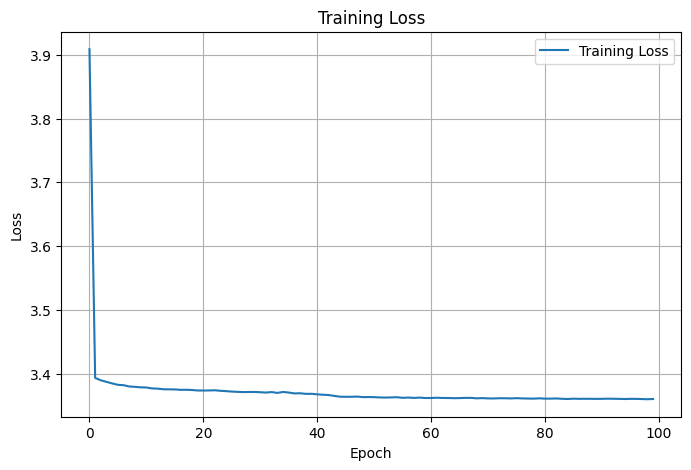

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(all_train_loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# training models
xgb_model = XGBRegressor(**xgb_params)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

cat_model = CatBoostRegressor(**cat_params, cat_features=cat_features)
cat_model.fit(X_train, y_train, eval_set=[(X_val, y_val)])

# lgb_model = LGBMRegressor(**lgb_params)
# lgb_model.fit(X_train, y_train)

In [17]:
xgb_pred_val = np.expm1(xgb_model.predict(X_val))
cat_pred_val = np.expm1(cat_model.predict(X_val))
# lgb_pred_val = np.expm1(lgb_model.predict(X_val))

all_pred = torch.tensor(np.array([xgb_pred_val, cat_pred_val]).T, dtype=torch.float32).to(device) # removed lgb_pred_val

y_val_pred = meta_model(all_pred)
y_val_pred = y_val_pred.cpu()
y_val_pred = y_val_pred.detach().numpy()

y_val_pred = np.minimum(y_val_pred, 314)
y_val_pred = np.maximum(y_val_pred, 0)

score = np.sqrt(mean_squared_log_error(y_val_pred, y_val0))
print(f"Validation Score :{score}")

Validation Score :0.059576241111718796


# Submission

In [18]:
df_test1 = make_feature_set1(df_test, test=True)

xgb_pred = np.expm1(xgb_model.predict(df_test1))
cat_pred = np.expm1(cat_model.predict(df_test1))
# lgb_pred = np.expm1(lgb_model.predict(df_test1))

all_pred = torch.tensor(np.array([xgb_pred, cat_pred]).T, dtype=torch.float32).to(device) # removed lgb_pred
# all_pred = np.array([xgb_pred, cat_pred, lgb_pred]).T

In [19]:
y_test_pred = meta_model(all_pred)
y_test_pred = y_test_pred.cpu()
y_test_pred = y_test_pred.detach().numpy()
y_test_pred = np.minimum(y_test_pred, 314)
y_test_pred = np.maximum(y_test_pred, 0)

In [20]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e5/sample_submission.csv")
submission['Calories'] = y_test_pred
submission.to_csv('submission.csv', index=False)
submission.head()

,id,Calories
0,750000,27.500425
1,750001,108.372993
2,750002,86.944527
3,750003,125.149391
4,750004,76.065598
